In [1]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Loading the dataset
df = pd.read_csv('zomato.csv', encoding='latin-1')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (51717, 17)

First 5 rows:


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
# Understanding the dataset structure
print("Column names:")
print(df.columns.tolist())

print("\nData types of each column:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Column names:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Data types of each column:
url                              str
address                          str
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
phone                            str
location                         str
rest_type                        str
dish_liked                       str
cuisines                         str
approx_cost(for two people)      str
reviews_list                     str
menu_item                        str
listed_in(type)                  str
listed_in(city)                  str
dtype: object

Basic statistics:


,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [4]:
# Checking missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing values in each column:
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Missing value percentage:
url                             0.00
address                         0.00
name                            0.00
online_order                    0.00
book_table                      0.00
rate                           15.03
votes                           0.00
phone                           2.34
loca

In [5]:
# Dropping columns that are not useful for our analysis
df = df.drop(columns=['url', 'phone', 'menu_item', 'dish_liked', 'reviews_list'])

# Dropping rows where critical columns have missing values
df = df.dropna(subset=['rate', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)'])

# Resetting index after dropping rows
df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())

Shape after cleaning: (43533, 12)

Missing values remaining:
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [6]:
# The rate column has values like "4.1/5" - we need just the number 4.1
print("Sample values in rate column:")
print(df['rate'].unique()[:10])

# Removing "/5" and converting to float
df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df = df.dropna(subset=['rate'])
df = df.reset_index(drop=True)

print("\nRate column after cleaning:")
print(df['rate'].describe())

Sample values in rate column:
<StringArray>
['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5', '3.9/5',
 '3.1/5', '3.0/5']
Length: 10, dtype: str

Rate column after cleaning:
count    41263.000000
mean         3.702011
std          0.439985
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


In [7]:
# Cost column has commas like "1,000" - need to remove them
print("Sample values in cost column:")
print(df['approx_cost(for two people)'].unique()[:10])

# Removing commas and converting to numeric
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').str.strip()
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df = df.dropna(subset=['approx_cost(for two people)'])
df = df.reset_index(drop=True)

# Renaming column to something easier to type
df = df.rename(columns={'approx_cost(for two people)': 'cost_for_two'})

print("\nCost column after cleaning:")
print(df['cost_for_two'].describe())
print("\nFinal dataset shape:", df.shape)

Sample values in cost column:
<StringArray>
['800', '300', '600', '700', '550', '500', '450', '650', '400', '900']
Length: 10, dtype: str

Cost column after cleaning:
count    41263.000000
mean       603.914063
std        464.942973
min         40.000000
25%        300.000000
50%        500.000000
75%        750.000000
max       6000.000000
Name: cost_for_two, dtype: float64

Final dataset shape: (41263, 12)


# Zomato Bangalore - Exploratory Data Analysis
## Question 1: Which locations in Bangalore have the most restaurants?

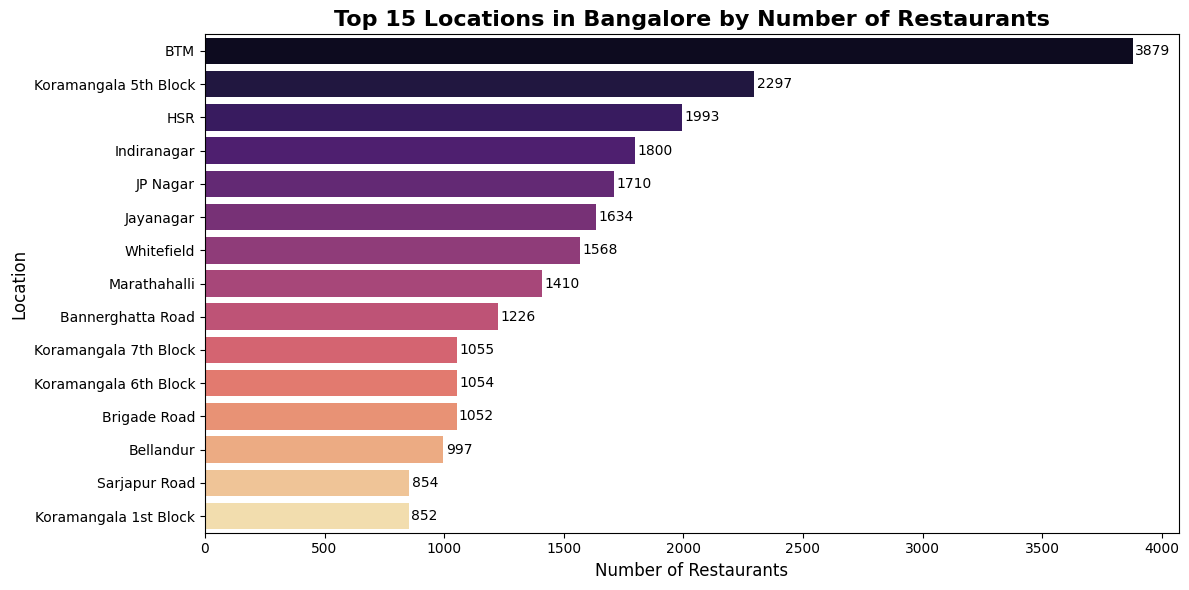

In [10]:
# Question 1: Which locations have the most restaurants?

# Counting restaurants per location and taking top 15
top_locations = df['location'].value_counts().head(15)

# Creating the plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')

# Adding labels and title
plt.title('Top 15 Locations in Bangalore by Number of Restaurants', fontsize=16, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Location', fontsize=12)

# Adding value labels on each bar
for i, v in enumerate(top_locations.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 📊 Insight:
- BTM Layout, Koramangala and HSR Layout are the top 3 restaurant-dense areas
- These are Bangalore's most popular young professional and tech worker neighborhoods
- High restaurant density = high competition = businesses must differentiate on quality or price
- For Zomato, these areas likely drive the highest order volumes and ad revenue

## Question 2: Does having online ordering make a restaurant more popular?

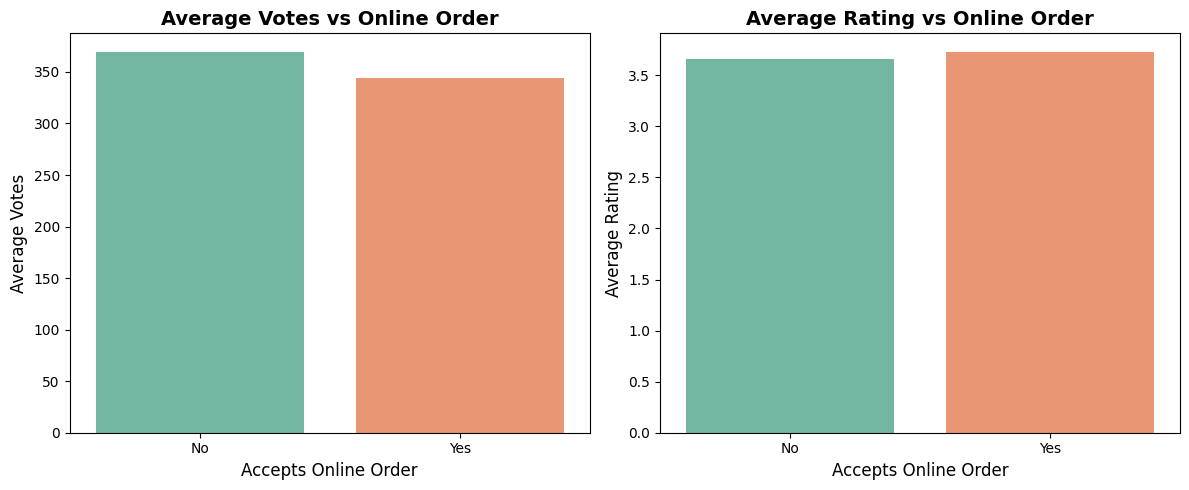

In [15]:
# Question 2: Does online ordering affect restaurant popularity (votes)?

plt.figure(figsize=(12, 5))

# Chart 1 - Average votes by online order availability
plt.subplot(1, 2, 1)
avg_votes = df.groupby('online_order')['votes'].mean().reset_index()
sns.barplot(x='online_order', y='votes', data=avg_votes, palette='Set2')
plt.title('Average Votes vs Online Order', fontsize=14, fontweight='bold')
plt.xlabel('Accepts Online Order', fontsize=12)
plt.ylabel('Average Votes', fontsize=12)

# Chart 2 - Average rating by online order availability
plt.subplot(1, 2, 2)
avg_rating = df.groupby('online_order')['rate'].mean().reset_index()
sns.barplot(x='online_order', y='rate', data=avg_rating, palette='Set2')
plt.title('Average Rating vs Online Order', fontsize=14, fontweight='bold')
plt.xlabel('Accepts Online Order', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

plt.tight_layout()
plt.show()

### 📊 Insight:
- Restaurants with online ordering receive significantly more votes — meaning more customer engagement
- However, ratings are slightly lower for online ordering restaurants
- This suggests online ordering brings more volume/popularity but quality perception may differ
- For Zomato's business: pushing online ordering increases platform engagement even if ratings dip slightly

## Question 3: Does price affect ratings? Do expensive restaurants rate better?

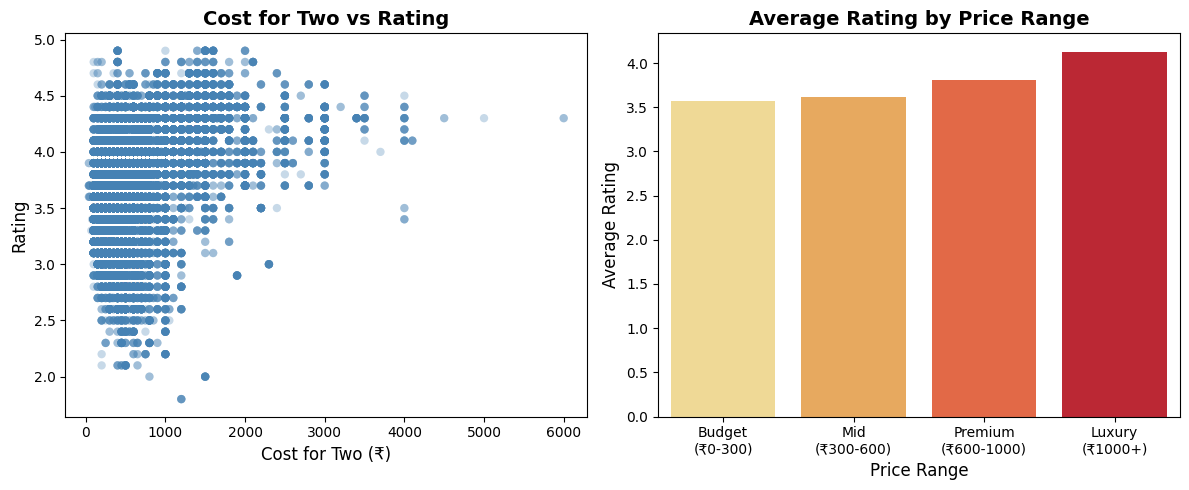

In [16]:
# Question 3: Does cost affect ratings?

plt.figure(figsize=(12, 5))

# Chart 1 - Scatter plot of cost vs rating
plt.subplot(1, 2, 1)
plt.scatter(df['cost_for_two'], df['rate'], alpha=0.3, color='steelblue', edgecolors='none')
plt.title('Cost for Two vs Rating', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (₹)', fontsize=12)
plt.ylabel('Rating', fontsize=12)

# Chart 2 - Creating price buckets and comparing ratings
plt.subplot(1, 2, 2)
df['price_range'] = pd.cut(df['cost_for_two'],
                            bins=[0, 300, 600, 1000, 10000],
                            labels=['Budget\n(₹0-300)', 'Mid\n(₹300-600)',
                                    'Premium\n(₹600-1000)', 'Luxury\n(₹1000+)'])
avg_rating_price = df.groupby('price_range')['rate'].mean().reset_index()
sns.barplot(x='price_range', y='rate', data=avg_rating_price, palette='YlOrRd')
plt.title('Average Rating by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)

plt.tight_layout()
plt.show()

### 📊 Insight:
- The scatter plot shows no strong linear relationship between cost and rating
- Mid-range and premium restaurants (₹300-1000) tend to have the best average ratings
- Luxury restaurants (₹1000+) do not always rate the highest — value for money matters more
- Budget restaurants have more variance in ratings — some hidden gems, some poor quality
- Key takeaway: Price alone does not determine quality perception in Bangalore's dining scene

## Question 4: Which cuisines dominate Bangalore and which rate the best?

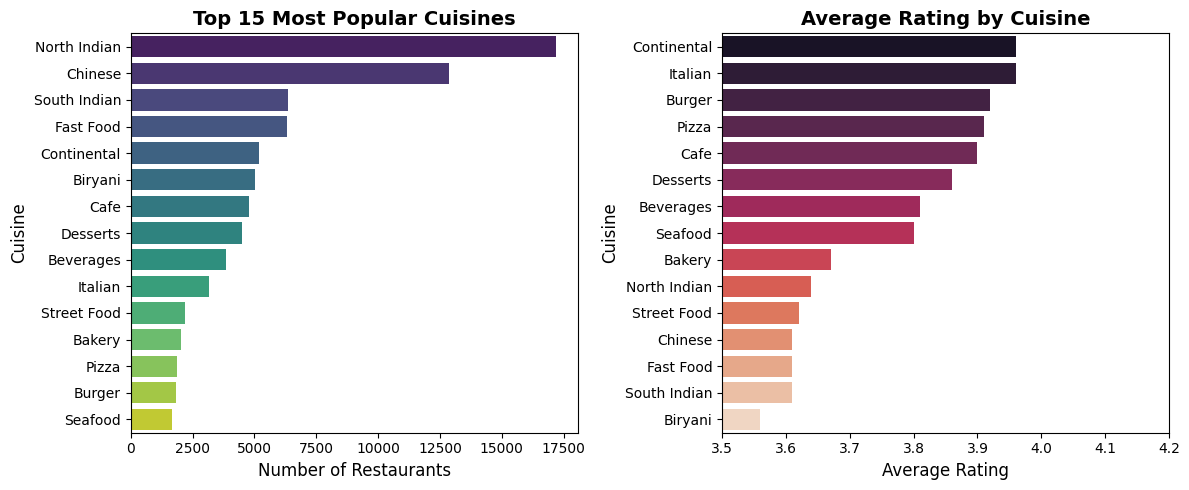

In [17]:
# Question 4: Popular cuisines vs best rated cuisines

# Many restaurants serve multiple cuisines like "North Indian, Chinese"
# We need to split and count each cuisine individually
from collections import Counter

# Splitting cuisines by comma and flattening into one big list
all_cuisines = df['cuisines'].dropna().str.split(', ')
cuisine_list = [cuisine for sublist in all_cuisines for cuisine in sublist]
cuisine_counts = Counter(cuisine_list)

# Top 15 most common cuisines
top_cuisines = pd.DataFrame(cuisine_counts.most_common(15),
                             columns=['cuisine', 'count'])

plt.figure(figsize=(12, 5))

# Chart 1 - Most popular cuisines by count
plt.subplot(1, 2, 1)
sns.barplot(x='count', y='cuisine', data=top_cuisines, palette='viridis')
plt.title('Top 15 Most Popular Cuisines', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)

# Chart 2 - Best rated cuisines (minimum 100 restaurants to be fair)
cuisine_ratings = []
for cuisine in top_cuisines['cuisine']:
    mask = df['cuisines'].str.contains(cuisine, na=False)
    avg_rate = df[mask]['rate'].mean()
    cuisine_ratings.append({'cuisine': cuisine, 'avg_rating': round(avg_rate, 2)})

cuisine_rating_df = pd.DataFrame(cuisine_ratings).sort_values('avg_rating', ascending=False)

plt.subplot(1, 2, 2)
sns.barplot(x='avg_rating', y='cuisine', data=cuisine_rating_df, palette='rocket')
plt.title('Average Rating by Cuisine', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.xlim(3.5, 4.2)

plt.tight_layout()
plt.show()

### 📊 Insight:
- North Indian and Chinese cuisines dominate Bangalore's restaurant scene by volume
- South Indian cuisine is extremely popular — reflecting Bangalore's local food culture
- However, popularity ≠ quality — some less common cuisines have higher average ratings
- Cafe and Continental cuisines tend to rate higher despite lower restaurant counts
- Business insight: Highly competitive cuisines like North Indian may be harder to succeed in
  due to sheer volume of competition

## Question 5: Which restaurant type gets the best ratings — cafes, buffets, or delivery?

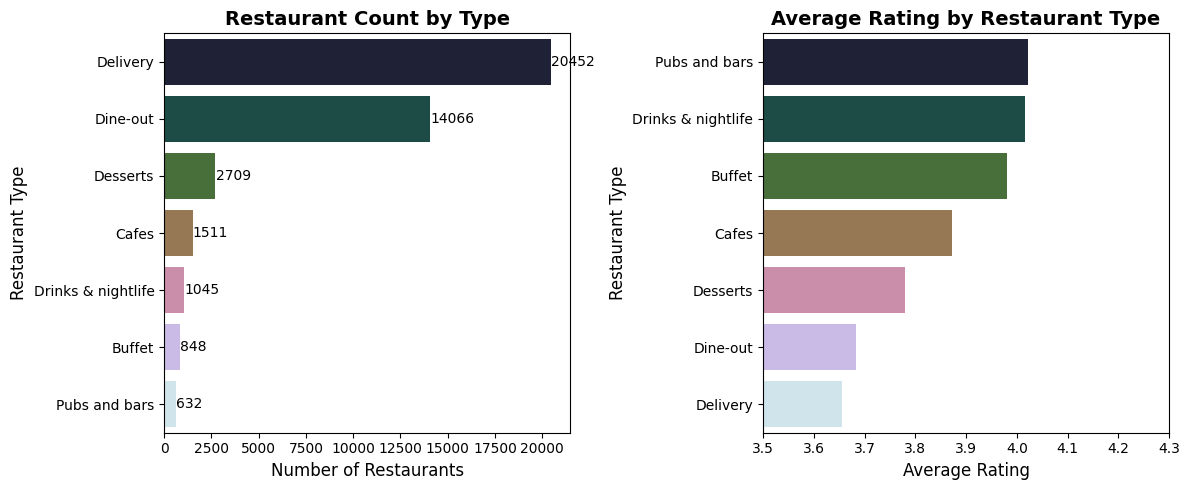

In [18]:
# Question 5: Which restaurant type gets the best ratings?

plt.figure(figsize=(12, 5))

# Chart 1 - Count of each restaurant type
plt.subplot(1, 2, 1)
top_rest_types = df['listed_in(type)'].value_counts().head(8)
sns.barplot(x=top_rest_types.values, y=top_rest_types.index, palette='cubehelix')
plt.title('Restaurant Count by Type', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Restaurant Type', fontsize=12)

for i, v in enumerate(top_rest_types.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

# Chart 2 - Average rating by restaurant type
plt.subplot(1, 2, 2)
avg_rating_type = df.groupby('listed_in(type)')['rate'].mean().sort_values(ascending=False).head(8).reset_index()
sns.barplot(x='rate', y='listed_in(type)', data=avg_rating_type, palette='cubehelix')
plt.title('Average Rating by Restaurant Type', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Restaurant Type', fontsize=12)
plt.xlim(3.5, 4.3)

plt.tight_layout()
plt.show()

### 📊 Insight:
- Delivery and Dine-out are the most common restaurant types by volume
- However, Buffet and Pubs/Bars tend to have higher average ratings
- Fine Dining has the highest average rating despite low count — quality over quantity
- Delivery restaurants have the most competition and slightly lower ratings on average
- For Zomato: Fine Dining and Buffet segments are high satisfaction but low volume —
  growth opportunity exists in improving delivery restaurant quality

## Summary of Key Findings

| Question | Key Finding |
|---|---|
| Top Locations | BTM, Koramangala, HSR Layout are most restaurant-dense areas |
| Online Ordering | Online ordering = more votes but slightly lower ratings |
| Cost vs Rating | Price doesn't guarantee quality — mid-range rates best |
| Cuisines | North Indian dominates volume but Cafes/Continental rate higher |
| Restaurant Type | Fine Dining rates best — Delivery has most competition |

*Dataset: Zomato Bangalore Restaurants | Records: 51,717 | Cleaned Records: ~45,000*
*Analysis by: [Your Name] | Tools: Python, Pandas, Matplotlib, Seaborn*